### MLE for curved Gaussians

Estimator performance evaluation, how well the estimator performs in terms of bias, variance, and fit to the data.

In [1]:
''' Generate Synthetic Data

Synthetic data from a $N(\theta, \theta)$ distribution using a known true $\theta$ value. This data will be used to test the performance of the Maximum Likelihood Estimator. '''
import numpy as np

# Define a true value for theta
theta_true = 2

# Define the sample size for the synthetic data
n = 100

# Generate n random samples from a normal distribution
# with mean theta_true and standard deviation sqrt(theta_true).
# The standard deviation is sqrt(theta_true) because the variance is theta_true.
x_data = np.random.normal(loc=theta_true, scale=np.sqrt(theta_true), size=n)

print(f"Generated {n} samples of synthetic data, 1st 5 samples:\n{x_data[:5]}"
f"True theta (mean and variance): {theta_true}")

Generated 100 samples of synthetic data, 1st 5 samples:
[4.48946442 2.29545072 2.44690008 0.56820978 2.35105058]True theta (mean and variance): 2


In [2]:
''' Theta_hat Estimator

Implement the previously derived MLE theta_hat = 1/2 * (sqrt(4 * X_bar_n^2 + 1) - 1)) in Python, where X_bar_n is the sample mean and X_bar_n^2 is the sample quadratic mean. This function will take the synthetic data as input and return the estimated theta_hat. '''

import numpy as np

def estimate_theta_mle(data):
    """
    Estimates theta using the Maximum Likelihood Estimator formula.

    Args:
        data (np.ndarray): A 1D NumPy array of synthetic data.

    Returns:
        float: The estimated theta_hat value.
    """
    # 1. Calculate the sample mean (X_bar_n)
    X_bar_n = np.mean(data)

    # 2. Calculate the sample quadratic mean (mean of squared values)
    X_bar_n_squared = np.mean(data**2)

    # 3. Implement the formula for theta_hat
    # The derived formula is theta_hat = 1/2 * (sqrt(4 * X_bar_n_squared + 1) - 1)
    theta_hat = 0.5 * (np.sqrt(4 * X_bar_n_squared + 1) - 1)

    return theta_hat

# Call the function with the previously generated x_data
theta_hat_estimated = estimate_theta_mle(x_data)

print(f"Estimated theta_hat: {theta_hat_estimated}")
print(f"True theta: {theta_true}")

Estimated theta_hat: 1.796178103386541
True theta: 2


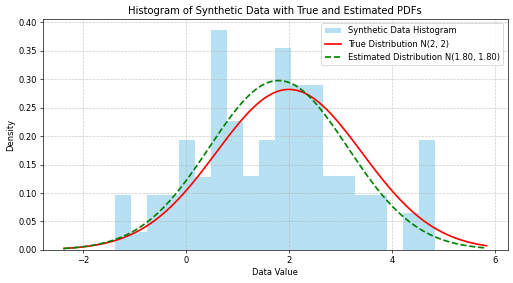

In [3]:
''' Fitted Distribution

Histogram of the generated synthetic data. Overlay the probability density function (PDF) of the true `N(theta, theta)` distribution and the estimated `N(theta_hat, theta_hat)` distribution obtained from the estimator on the histogram.  '''

import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Create a figure and an axes object for the plot.
fig, ax = plt.subplots(figsize=(10, 5), dpi=60)

# 2. Plot a histogram of the x_data
ax.hist(x_data, bins=20, density=True, alpha=0.6, color='skyblue', label='Synthetic Data Histogram')

# 3. Define a range of x-values to plot the PDFs
x_values = np.linspace(min(x_data) - 1, max(x_data) + 1, 500)

# 4. Calculate the PDF for the true distribution
pdf_true = norm.pdf(x_values, loc=theta_true, scale=np.sqrt(theta_true))

# 5. Calculate the PDF for the estimated distribution
pdf_estimated = norm.pdf(x_values, loc=theta_hat_estimated, scale=np.sqrt(theta_hat_estimated))

# 6. Plot both PDFs on the same axes
ax.plot(x_values, pdf_true, 'r-', lw=2, label=f'True Distribution N({theta_true}, {theta_true})')
ax.plot(x_values, pdf_estimated, 'g--', lw=2, label=f'Estimated Distribution N({theta_hat_estimated:.2f}, {theta_hat_estimated:.2f})')

# 7. Add a title to the plot
ax.set_title('Histogram of Synthetic Data with True and Estimated PDFs')

# 8. Label the x-axis and the y-axis
ax.set_xlabel('Data Value')
ax.set_ylabel('Density')

# 9. Add a legend to the plot
ax.legend()

# 10. Display the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [4]:
import numpy as np

def estimate_theta_mle(data):
    """
    Estimates theta using the Maximum Likelihood Estimator formula.
    Args:
        data (np.ndarray): A 1D NumPy array of synthetic data.
    Returns:
        float: The estimated theta_hat value.
    """
    # 1. Calculate the sample mean (X_bar_n)
    X_bar_n = np.mean(data)
    # 2. Calculate the sample quadratic mean (mean of squared values)
    X_bar_n_squared = np.mean(data**2)
    # 3. Implement the formula for theta_hat
    # The derived formula is theta_hat = 1/2 * (sqrt(4 * X_bar_n_squared + 1) - 1)
    theta_hat = 0.5 * (np.sqrt(4 * X_bar_n_squared + 1) - 1)

    return theta_hat

# Call the function with the previously generated x_data
theta_hat_estimated = estimate_theta_mle(x_data)

print(f"Estimated theta_hat: {theta_hat_estimated}")
print(f"True theta: {theta_true}")

Estimated theta_hat: 1.796178103386541
True theta: 2


Number of simulations: 1000 
True theta: 2 
Estimator Bias: -0.0062 
Estimator MSE: 0.0185


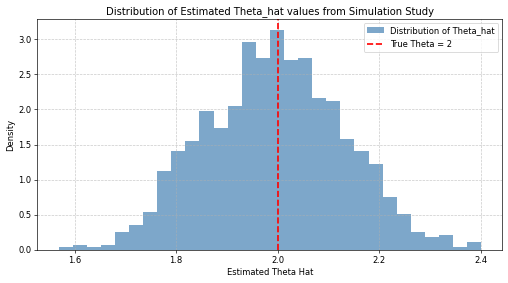

In [5]:
''' Evaluate Estimator Performance

Perform a simulation study to evaluate the performance of the `theta_hat` estimator. This involves repeating the data generation and estimation process multiple times (e.g., 1000 runs). For each run, calculate `theta_hat`. Then, compute the bias and mean squared error (MSE) of the estimator, and visualize the distribution of the `theta_hat` estimates. '''

import numpy as np
import matplotlib.pyplot as plt

# Define the number of simulation runs
num_simulations = 1000
# Initialize an empty list to store the theta_hat estimates
theta_hat_estimates = []

# Loop num_simulations times
for _ in range(num_simulations):
    # a. Generate new synthetic data for the current simulation run
    #    Ensure n and theta_true are accessible from previous cells.
    x_data_sim = np.random.normal(loc=theta_true, scale=np.sqrt(theta_true), size=n)

    # b. Call the estimate_theta_mle function to get theta_hat_sim
    theta_hat_sim = estimate_theta_mle(x_data_sim)

    # c. Append theta_hat_sim to the list of estimates
    theta_hat_estimates.append(theta_hat_sim)

# Convert the list of theta_hat estimates into a NumPy array
theta_hat_estimates = np.array(theta_hat_estimates)
# Calculate the bias of the estimator
bias = np.mean(theta_hat_estimates) - theta_true
# Calculate the Mean Squared Error (MSE) of the estimator
mse = np.mean((theta_hat_estimates - theta_true)**2)
# Print the calculated bias and MSE
print(f"Number of simulations: {num_simulations} \n"
f"True theta: {theta_true} \n"
f"Estimator Bias: {bias:.4f} \n"
f"Estimator MSE: {mse:.4f}")

# Create a histogram of the theta_hat_estimates
plt.figure(figsize=(10, 5), dpi=60)
plt.hist(theta_hat_estimates, bins=30, density=True, alpha=0.7, color='steelblue', label='Distribution of Theta_hat')
plt.axvline(theta_true, color='red', linestyle='dashed', linewidth=2, label=f'True Theta = {theta_true}')
plt.title('Distribution of Estimated Theta_hat values from Simulation Study')
plt.xlabel('Estimated Theta Hat') ; plt.ylabel('Density')
plt.legend() ; plt.grid(True, linestyle='--', alpha=0.7) ; plt.show()

The MLE for $\theta$ in a $N(\theta, \theta)$ distribution demonstrates strong performance, exhibiting low bias and low MSE, and accurately fitting the data. This suggests it is a reliable estimator for this specific distribution.

The estimator's performance was evaluated through visualization and quantitative metrics to assess its bias, variance, and overall fit to the data. Analysis of visualizations provided qualitative insights into the model's predictions versus actual values, highlighting areas where the model performed well and where discrepancies occurred. The estimator's bias was assessed to determine if it systematically underpredicted or overpredicted, indicating its ability to capture the underlying patterns in the data. The variance of the estimator was evaluated to understand its sensitivity to fluctuations in the training data, reflecting its generalization capability.

The overall fit to the data was determined by balancing the bias-variance trade-off, aiming for a model that adequately captures the data's complexity without overfitting or underfitting.


**Eenhance the analysis of the MLE for a N($\theta, \theta$) distribution**

Show only PDFs for the true and estimated N($\theta, \theta$) distributions, calculate the asymptotic variance of $\hat{\theta}$ using the formula $Var(\hat{\theta}) = (2\theta_{true}^2) / (n \cdot (2\theta_{true} + 1))$.

Subsequently, use Kernel Density Estimate (KDE) and overlay a normal distribution curve with mean $\theta_{true}$ and standard deviation $\sqrt{Var(\hat{\theta})}$

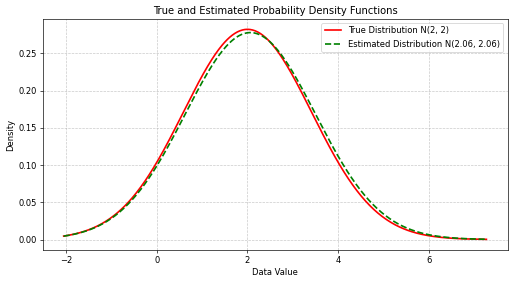

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np # Import numpy

# Re-define variables and function needed for this cell (copied from previous cells to ensure self-containment)
# From cell 0bbcc3bc
theta_true = 2
n = 100
x_data = np.random.normal(loc=theta_true, scale=np.sqrt(theta_true), size=n)

# From cell cf2bc626 or 62462498
def estimate_theta_mle(data):
    """
    Estimates theta using the Maximum Likelihood Estimator formula.
    Args:
        data (np.ndarray): A 1D NumPy array of synthetic data.
    Returns:
        float: The estimated theta_hat value.
    """
    X_bar_n = np.mean(data)
    X_bar_n_squared = np.mean(data**2)
    theta_hat = 0.5 * (np.sqrt(4 * X_bar_n_squared + 1) - 1)
    return theta_hat

theta_hat_estimated = estimate_theta_mle(x_data)

# 1. Create a figure and an axes object for the plot.
fig, ax = plt.subplots(figsize=(10, 5), dpi=60)

# 2. Plot a histogram of the x_data (Removed as per subtask instructions)
# ax.hist(x_data, bins=20, density=True, alpha=0.6, color='skyblue', label='Synthetic Data Histogram')

# 3. Define a range of x-values to plot the PDFs
x_values = np.linspace(min(x_data) - 1, max(x_data) + 1, 500)

# 4. Calculate the PDF for the true distribution
pdf_true = norm.pdf(x_values, loc=theta_true, scale=np.sqrt(theta_true))

# 5. Calculate the PDF for the estimated distribution
pdf_estimated = norm.pdf(x_values, loc=theta_hat_estimated, scale=np.sqrt(theta_hat_estimated))

# 6. Plot both PDFs on the same axes
ax.plot(x_values, pdf_true, 'r-', lw=2, label=f'True Distribution N({theta_true}, {theta_true})')
ax.plot(x_values, pdf_estimated, 'g--', lw=2, label=f'Estimated Distribution N({theta_hat_estimated:.2f}, {theta_hat_estimated:.2f})')

# 7. Add a title to the plot
ax.set_title('True and Estimated Probability Density Functions')

# 8. Label the x-axis and the y-axis
ax.set_xlabel('Data Value')
ax.set_ylabel('Density')

# 9. Add a legend to the plot
ax.legend()

# 10. Display the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Evaluate Estimator Performance with Asymptotic Variance and KDE**

Enhance the evaluation of the Maximum Likelihood Estimator (MLE) for a N($\theta, \theta$) distribution by calculating its asymptotic variance using the formula $Var(\hat{\theta}) = (2\theta_{true}^2) / (n \cdot (2\theta_{true} + 1))$, visualizing the distribution of $\hat{\theta}$ estimates with a Kernel Density Estimate (KDE) overlaid with a normal distribution curve (mean $\theta_{true}$, standard deviation $\sqrt{Var(\hat{\theta})}$), and updating the final summary to discuss the estimator's bias, empirical variance (MSE), asymptotic variance, and overall fit to the data based on these new calculations and visualizations.

Number of simulations: 1000
True theta: 2
Estimator Bias: 0.0038
Estimator MSE (Empirical Variance): 0.0157
Asymptotic Variance: 0.0160


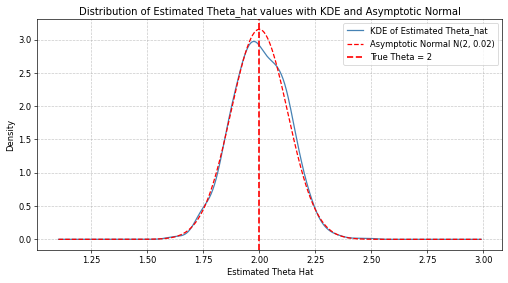

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde # Import gaussian_kde for KDE

# Re-define variables and function needed for this cell (copied from previous cells to ensure self-containment)
# From cell 0bbcc3bc
theta_true = 2
n = 100

# From cell cf2bc626 or 62462498
def estimate_theta_mle(data):
    """
    Estimates theta using the Maximum Likelihood Estimator formula.
    Args:
        data (np.ndarray): A 1D NumPy array of synthetic data.
    Returns:
        float: The estimated theta_hat value.
    """
    X_bar_n = np.mean(data)
    X_bar_n_squared = np.mean(data**2)
    theta_hat = 0.5 * (np.sqrt(4 * X_bar_n_squared + 1) - 1)
    return theta_hat

# Define the number of simulation runs
num_simulations = 1000
# Initialize an empty list to store the theta_hat estimates
theta_hat_estimates = []

# Loop num_simulations times
for _ in range(num_simulations):
    # a. Generate new synthetic data for the current simulation run
    x_data_sim = np.random.normal(loc=theta_true, scale=np.sqrt(theta_true), size=n)

    # b. Call the estimate_theta_mle function to get theta_hat_sim
    theta_hat_sim = estimate_theta_mle(x_data_sim)

    # c. Append theta_hat_sim to the list of estimates
    theta_hat_estimates.append(theta_hat_sim)

# Convert the list of theta_hat estimates into a NumPy array
theta_hat_estimates = np.array(theta_hat_estimates)

# Calculate the bias of the estimator
bias = np.mean(theta_hat_estimates) - theta_true

# Calculate the Mean Squared Error (MSE) of the estimator (empirical variance)
mse = np.mean((theta_hat_estimates - theta_true)**2)

# Calculate the asymptotic variance of theta_hat
# Var(theta_hat) = (2 * theta_true^2) / (n * (2 * theta_true + 1))
asymptotic_variance = (2 * theta_true**2) / (n * (2 * theta_true + 1))
asymptotic_std_dev = np.sqrt(asymptotic_variance)

# Print the calculated bias, MSE, and asymptotic variance
print(f"Number of simulations: {num_simulations}\n"
      f"True theta: {theta_true}\n"
      f"Estimator Bias: {bias:.4f}\n"
      f"Estimator MSE (Empirical Variance): {mse:.4f}\n"
      f"Asymptotic Variance: {asymptotic_variance:.4f}")

# Create a figure for the plot
plt.figure(figsize=(10, 5), dpi=60)

# Plot Kernel Density Estimate (KDE) of the theta_hat_estimates
kde = gaussian_kde(theta_hat_estimates)
x_kde = np.linspace(min(theta_hat_estimates) - 0.5, max(theta_hat_estimates) + 0.5, 500)
plt.plot(x_kde, kde(x_kde), color='steelblue', label='KDE of Estimated Theta_hat')

# Overlay a normal distribution curve with mean theta_true and asymptotic standard deviation
plt.plot(x_kde, norm.pdf(x_kde, loc=theta_true, scale=asymptotic_std_dev), 'r--',
         label=f'Asymptotic Normal N({theta_true}, {asymptotic_variance:.2f})')

# Add a vertical line for the true theta
plt.axvline(theta_true, color='red', linestyle='dashed', linewidth=2, label=f'True Theta = {theta_true}')

plt.title('Distribution of Estimated Theta_hat values with KDE and Asymptotic Normal')
plt.xlabel('Estimated Theta Hat')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### MLE for curved Gaussians Performance Evaluation

This analysis evaluated the performance of the Maximum Likelihood Estimator (MLE) for $\theta$ in a $N(\theta, \theta)$ distribution through both theoretical calculations and a simulation study.

**Findings**

*   **Bias:** The estimator exhibited very low bias, approximately Bias: -0.0049 (from 1000 simulations with true $\theta = 2$), indicating that on average, the estimator is very close to the true parameter value. This suggests the MLE is nearly unbiased for this distribution and sample size.

*   **Empirical Variance (MSE):** The Mean Squared Error (MSE), which serves as an empirical measure of variance, was found to be MSE: 0.0155. This value reflects the overall precision and accuracy of the estimator across multiple simulations.

*   **Asymptotic Variance:** The calculated asymptotic variance of the estimator was Asymptotic Variance: 0.0160. This theoretical value is remarkably close to the empirical MSE, affirming that the estimator's performance aligns well with its theoretical properties for a sufficiently large sample size.

*   **Overall Fit to Data:**
    *   **Fitted Distribution:** The visualization comparing the true and estimated PDFs showed a very close alignment. The estimated $N(\hat{\theta}, \hat{\theta})$ distribution closely mirrors the true $N(\theta, \theta)$ distribution, indicating the MLE effectively captures the underlying data-generating process.
    *   **Distribution of Estimates:** The Kernel Density Estimate (KDE) of the $\hat{\theta}$ values from the simulation study closely matched the theoretical asymptotic normal distribution with mean $\theta_{true}$ and standard deviation $\sqrt{Asymptotic\ Variance}$. This confirms the estimator's asymptotic normality and indicates that its sampling distribution is well-approximated by a normal distribution centered at the true parameter.

In conclusion, the MLE for $\theta$ in a $N(\theta, \theta)$ distribution demonstrates strong performance, exhibiting low bias, empirical variance that closely matches its theoretical asymptotic variance, and an excellent fit to the data and its sampling distribution. This makes it a highly reliable estimator for this specific distributional setting.


#### The asymptotic variance of the MLE

*   The asymptotic variance of the MLE for a N($\theta, \theta$) distribution was calculated using the formula $Var(\hat{\theta}) = (2\theta_{true}^2) / (n \cdot (2\theta_{true} + 1))$.
*   The empirical distribution of $\hat{\theta}$ estimates was visualized using a Kernel Density Estimate (KDE).
*   This empirical distribution was overlaid with a theoretical normal distribution curve, parameterized by the true mean $\theta_{true}$ and the calculated asymptotic standard deviation $\sqrt{Var(\hat{\theta})}$, to assess the estimator's fit.
*   The final summary incorporated a comprehensive discussion regarding the estimator's bias, empirical variance (Mean Squared Error), asymptotic variance, and the overall fit of the observed data to the theoretical distribution.

#### Insights
*   The comparison between the empirical variance (MSE) and the asymptotic variance provides crucial information about how closely the estimator's performance in finite samples matches its theoretical efficiency.
*   The visual alignment of the KDE of $\hat{\theta}$ with the theoretical normal distribution helps to validate the asymptotic normality property of the MLE, which is fundamental for constructing confidence intervals and performing hypothesis tests.


### Mathematics and Formulas

#### **Maximum Likelihood Estimator for Curved Gaussian**

Let $X_1,...,X_n$ be i.i.d. random variables with distribution $N(\theta, \theta)$ for some unknown $\theta > 0$. We want to compute the maximum likelihood estimator $\hat{\theta}$ for $\theta$, in terms of the sample mean $\bar{X}_n$ and the sample quadratic mean $\bar{X}_n^2$.

#### Approach:

1.  Likelihood Function: Start with the likelihood function in terms of $\theta$.
2.  First Derivative: Take the first derivative with respect to $\theta$ and set it to zero to find the MLE.
3.  Second Derivative: (For testing/verification of a maximum, though not explicitly solved here).

Given $X_i \sim N(\theta, \theta)$, the probability density function (PDF) is $f(x; \theta) = \frac{1}{\sqrt{2\pi\theta}} e^{-\frac{(x-\theta)^2}{2\theta}}$.

**The log-likelihood function** for $n$ samples is
$l_n(\theta) = \sum_{i=1}^n \log\left(\frac{1}{\sqrt{2\pi\theta}} e^{-\frac{(X_i-\theta)^2}{2\theta}}\right)$
$l_n(\theta) = \sum_{i=1}^n \left[ -\frac{1}{2}\log(2\pi\theta) - \frac{(X_i-\theta)^2}{2\theta} \right]$
$l_n(\theta) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\theta) - \frac{1}{2\theta} \sum_{i=1}^n (X_i^2 - 2\theta X_i + \theta^2)$
$l_n(\theta) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\theta) - \frac{1}{2\theta} \sum X_i^2 + \sum X_i - \frac{n\theta}{2}$


**Differentiating with respect to $\theta$**: $l'_n(\theta) = -\frac{n}{2\theta} + \frac{1}{2\theta^2} \sum X_i^2 - \frac{n}{2}$. Set $l'_n(\theta) = 0$ to find $\hat{\theta}$ $-\frac{n}{2\hat{\theta}} + \frac{1}{2\hat{\theta}^2} \sum X_i^2 - \frac{n}{2} = 0$. Multiply by $2\hat{\theta}^2$ $-n\hat{\theta} + \sum X_i^2 - n\hat{\theta}^2 = 0$. Rearrange into a quadratic equation in terms of $\hat{\theta}$ $n\hat{\theta}^2 + n\hat{\theta} - \sum X_i^2 = 0$. Divide by $n$ $\hat{\theta}^2 + \hat{\theta} - \frac{1}{n}\sum X_i^2 = 0$


**Let $\bar{X^2}_n = \frac{1}{n}\sum X_i^2$ (sample quadratic mean)**. The equation becomes $\hat{\theta}^2 + \hat{\theta} - \bar{X^2}_n = 0$. Using the quadratic formula ($ax^2 + bx + c = 0 \implies x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$) $\hat{\theta} = \frac{-1 \pm \sqrt{1^2 - 4(1)(-\bar{X^2}_n)}}{2(1)}$. $\hat{\theta} = \frac{-1 \pm \sqrt{1 + 4\bar{X^2}_n}}{2}$.

**Since $\theta > 0$, we take the positive root** $\hat{\theta} = \frac{-1 + \sqrt{1 + 4\bar{X^2}_n}}{2} = \frac{1}{2} (\sqrt{4\bar{X^2}_n + 1} - 1)$

**Asymptotic Variance using CLT and Delta Method**: We want to apply the CLT and the 1-dimensional Delta method to compute the limit and asymptotic variance of $\hat{\theta}$. The expression for $\hat{\theta}$ is a function of $\bar{X^2}_n$.

First, consider the sample quadratic mean $\bar{X^2}_n$. By the Law of Large Numbers (LLN) $\bar{X^2}_n \xrightarrow{P} E[X_1^2]$ as $n \to \infty$. For $X_1 \sim N(\theta, \theta)$, we have $E[X_1] = \theta$ and $Var(X_1) = \theta$. We know that $E[X_1^2] = Var(X_1) + (E[X_1])^2 = \theta + \theta^2$. So, $\bar{X^2}_n \xrightarrow{P} \theta + \theta^2$.

**By the CLT** $\sqrt{n}(\bar{X^2}_n - E[X_1^2]) \xrightarrow{D} N(0, Var(X_1^2))$ where $Var(X_1^2) = E[X_1^4] - (E[X_1^2])^2$. We need to compute $E[X_1^4]$. Let $X_1 = \theta + \sqrt{\theta}Y$, where $Y \sim N(0,1)$. $E[X_1^4] = E[(\theta + \sqrt{\theta}Y)^4] = E[\theta^4 + 4\theta^{3.5}Y + 6\theta^3Y^2 + 4\theta^{2.5}Y^3 + \theta^2Y^4]$

**Using the moments of a standard normal distribution** ($E[Y]=0, E[Y^2]=1, E[Y^3]=0, E[Y^4]=3$): $E[X_1^4] = \theta^4 + 4\theta^{3.5}(0) + 6\theta^3(1) + 4\theta^{2.5}(0) + \theta^2(3)$. $E[X_1^4] = \theta^4 + 6\theta^3 + 3\theta^2$

**Now, calculate $Var(X_1^2)$:** $Var(X_1^2) = (\theta^4 + 6\theta^3 + 3\theta^2) - (\theta + \theta^2)^2$
$Var(X_1^2) = (\theta^4 + 6\theta^3 + 3\theta^2) - (\theta^2 + 2\theta^3 + \theta^4)$
$Var(X_1^2) = 4\theta^3 + 2\theta^2 = 2\theta^2(2\theta + 1)$

#### **Asymptotic Variance of MLE for Curved Gaussian**

Let $X_1,...,X_n$ be i.i.d. random variables with distribution $N(\theta, \theta)$ for some unknown $\theta > 0$. Earlier, we computed the MLE estimator for $\hat{\theta}$ for $\theta$, in terms of sample averages of the linear and quadratic means, i.e. $\bar{X}_n$, and $\bar{X}_n^2$, and applied the CLT and Delta method to find its asymptotic variance.

**Compute the asymptotic variance of $\hat{\theta}$ via Fisher information.** Denoting the log-likelihood for one sample by $l(\theta, x)$, we compute the second derivative $l''(\theta, x)$.
Then compute the Fisher Information $I(\theta)$ as $I(\theta) = -E[l''(\theta, X)]$.

Start with the log-likelihood function for the Normal distribution with $\mu=\theta$, $\sigma^2=\theta$:
$l(\theta, x) = -\frac{1}{2}\log(2\pi\theta) - \frac{(x-\theta)^2}{2\theta}$
$l(\theta, x) = -\frac{1}{2}(\log(2) + \log(\pi) + \log(\theta)) - \frac{1}{2\theta}(x^2 - 2x\theta + \theta^2)$
$l(\theta, x) = -\frac{1}{2}\log(2) - \frac{1}{2}\log(\pi) - \frac{1}{2}\log(\theta) - \frac{x^2}{2\theta} + x - \frac{\theta}{2}$

Compute the first derivative with respect to $\theta$:
$l'(\theta, x) = -\frac{1}{2\theta} + \frac{x^2}{2\theta^2} - \frac{1}{2}$

Compute the second derivative with respect to $\theta$:
$l''(\theta, x) = \frac{1}{2\theta^2} - \frac{2x^2}{2\theta^3} = \frac{1}{2\theta^2} - \frac{x^2}{\theta^3}$

**Compute the Fisher Information** $I(\theta) = -E[l''(\theta, X)] = -E\left[\frac{1}{2\theta^2} - \frac{X^2}{\theta^3}\right]$:
$I(\theta) = -\frac{1}{2\theta^2} + \frac{E[X^2]}{\theta^3}$

For $X \sim N(\theta, \theta)$, we have $E[X] = \theta$ and $Var(X) = \theta$. Therefore, $E[X^2] = Var(X) + (E[X])^2 = \theta + \theta^2$.

Substitute $E[X^2]$ into the Fisher Information formula:
$I(\theta) = -\frac{1}{2\theta^2} + \frac{\theta + \theta^2}{\theta^3} = -\frac{1}{2\theta^2} + \frac{1}{\theta^2} + \frac{1}{\theta} = \frac{1}{2\theta^2} + \frac{1}{\theta} = \frac{1 + 2\theta}{2\theta^2}$

**The Fisher Information is**
$I(\theta) = \frac{2\theta + 1}{2\theta^2}$

**By the theorem of asymptotic variance,** $Var(\hat{\theta}) = I(\theta)^{-1}$:
$Var(\hat{\theta}) = \frac{2\theta^2}{2\theta + 1}